In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import inspect
from tqdm import tqdm

In [2]:
batch_size = 32

In [3]:
model_dictionary = {m[0]:m[1] for m in inspect.getmembers(tf.keras.applications, inspect.isfunction)}

In [4]:
train = tf.keras.utils.image_dataset_from_directory(
  "Insects",
  validation_split=0.2,
  subset="training",
  seed=123,
  batch_size=batch_size)

validation = tf.keras.utils.image_dataset_from_directory(
  "Insects",
  validation_split=0.2,
  subset="validation",
  seed=123,
  batch_size=batch_size)

class_names = train.class_names

Found 3336 files belonging to 5 classes.
Using 2669 files for training.
Found 3336 files belonging to 5 classes.
Using 667 files for validation.


In [5]:
num_train = 2669
num_validation = 667
num_classes = 5
num_iterations = int(num_train/batch_size)

print(f'Num train images: {num_train} \
        \nNum validation images: {num_validation} \
        \nNum classes: {num_classes} \
        \nNum iterations per epoch: {num_iterations}')

Num train images: 2669         
Num validation images: 667         
Num classes: 5         
Num iterations per epoch: 83


In [6]:
def normalize_img(image, label, img_size):
    # Resize image to the desired img_size and normalize it
    # One hot encode the label
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)/255.
    label = tf.one_hot(label, depth=num_classes)
    return image, label

def preprocess_data(train, validation, img_size):
    # Apply the normalize_img function on all train and validation data and create batches
    train_processed = train.map(lambda image, label: normalize_img(image, label, img_size))

    # If your data is already batched (eg, when using the image_dataset_from_directory function), remove .batch(batch_size)
    train_processed = train_processed.repeat()

    validation_processed = validation.map(lambda image, label: normalize_img(image, label, img_size))

    # If your data is already batched (eg, when using the image_dataset_from_directory function), remove .batch(batch_size)
    #validation_processed = validation_processed

    return train_processed, validation_processed

In [7]:
train_processed_224, validation_processed_224 = preprocess_data(train, validation, img_size=[224,224])
train_processed_331, validation_processed_331 = preprocess_data(train, validation, img_size=[331,331])

In [8]:
model_benchmarks = {'model_name': [], 'num_model_params': [], 'validation_accuracy': []}

for model_name, model in tqdm(model_dictionary.items()):
    # Special hadling for "NASNetLarge" since it require input images with size (331,331)
    if 'NASNetLarge' in model_name:
        input_shape=(331, 331, 3)
        train_processed = train_processed_331
        validation_processed = validation_processed_331
    else:
        input_shape=(224,224,3)
        train_processed = train_processed_224
        validation_processed = validation_processed_224

    # Load the pre-trained model with global average pooling as the last layerand freeze the modelweights
    pre_trained_model = model(include_top=False, pooling='avg', input_shape=input_shape)
    pre_trained_model.trainable = False

    # Custom modifications on top of pre-trained model and fit
    clf_model = tf.keras.models.Sequential()
    clf_model.add(pre_trained_model)
    clf_model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
    clf_model.compile(loss='categorical_crossentropy', metrics=['accuracy'])
    history = clf_model.fit(train_processed, epochs=3, validation_data=validation_processed, steps_per_epoch=num_iterations)

    # Calculate all relevant metrics
    model_benchmarks['model_name'].append(model_name)
    model_benchmarks['num_model_params'].append(pre_trained_model.count_params())
    model_benchmarks['validation_accuracy'].append(history.history['val_accuracy'][-1])

  0%|          | 0/71 [00:00<?, ?it/s]

350926856/350926856 [==============================] - 16s 0us/step
Epoch 1/3
83/83 [==============================] - 1125s 14s/step - loss: 0.8791 - accuracy: 0.7018 - val_loss: 0.7288 - val_accuracy: 0.7256
Epoch 2/3
83/83 [==============================] - 3164s 39s/step - loss: 0.6179 - accuracy: 0.7831 - val_loss: 0.6469 - val_accuracy: 0.7721
Epoch 3/3
83/83 [==============================] - 1116s 13s/step - loss: 0.5462 - accuracy: 0.8203 - val_loss: 0.6061 - val_accuracy: 0.7541


  1%|▏         | 1/71 [1:30:25<105:29:19, 5425.14s/it]

785596384/785596384 [==============================] - 23s 0us/step
Epoch 1/3
83/83 [==============================] - 1812s 22s/step - loss: 0.9011 - accuracy: 0.6657 - val_loss: 0.7435 - val_accuracy: 0.6987
Epoch 2/3
83/83 [==============================] - 1792s 22s/step - loss: 0.6387 - accuracy: 0.7546 - val_loss: 0.6745 - val_accuracy: 0.7061
Epoch 3/3
83/83 [==============================] - 1793s 22s/step - loss: 0.5792 - accuracy: 0.7751 - val_loss: 0.6330 - val_accuracy: 0.7511


  3%|▎         | 2/71 [3:00:48<103:57:54, 5424.27s/it]

...

 97%|█████████▋| 69/71 [15:34:55<34:51, 1045.82s/it]  

80134624/80134624 [==============================] - 4s 0us/step
Epoch 1/3
83/83 [==============================] - 213s 3s/step - loss: 1.4555 - accuracy: 0.4209 - val_loss: 1.3039 - val_accuracy: 0.5187
Epoch 2/3
83/83 [==============================] - 211s 3s/step - loss: 1.1698 - accuracy: 0.6068 - val_loss: 1.1188 - val_accuracy: 0.6372
Epoch 3/3
83/83 [==============================] - 220s 3s/step - loss: 1.0219 - accuracy: 0.6655 - val_loss: 1.0029 - val_accuracy: 0.6882


 99%|█████████▊| 70/71 [15:45:43<15:26, 926.58s/it] 

83683744/83683744 [==============================] - 4s 0us/step
Epoch 1/3
83/83 [==============================] - 82s 946ms/step - loss: 0.4234 - accuracy: 0.8599 - val_loss: 0.2571 - val_accuracy: 0.9175
Epoch 2/3
83/83 [==============================] - 82s 987ms/step - loss: 0.2210 - accuracy: 0.9211 - val_loss: 0.2194 - val_accuracy: 0.9220
Epoch 3/3
83/83 [==============================] - 79s 952ms/step - loss: 0.1867 - accuracy: 0.9352 - val_loss: 0.2126 - val_accuracy: 0.9235


100%|██████████| 71/71 [15:49:51<00:00, 802.70s/it]


In [9]:
# Convert Results to DataFrame for easy viewing
benchmark_df = pd.DataFrame(model_benchmarks)

# Sort in ascending order of num_model_params column
benchmark_df.sort_values('validation_accuracy', inplace=True)

# Write results to csv file
benchmark_df.to_csv('benchmark.csv', index=False)
benchmark_df

,model_name,num_model_params,validation_accuracy
9,EfficientNetB1,6575239,0.220390
51,RegNetY080,37248812,0.245877
11,EfficientNetB3,10783535,0.247376
16,EfficientNetV2B0,5919312,0.248876
36,RegNetX032,14350112,0.265367
...,...,...,...
26,MobileNetV2,2257984,0.923538
70,Xception,20861480,0.923538
7,DenseNet201,18321984,0.934033
6,DenseNet169,12642880,0.937032


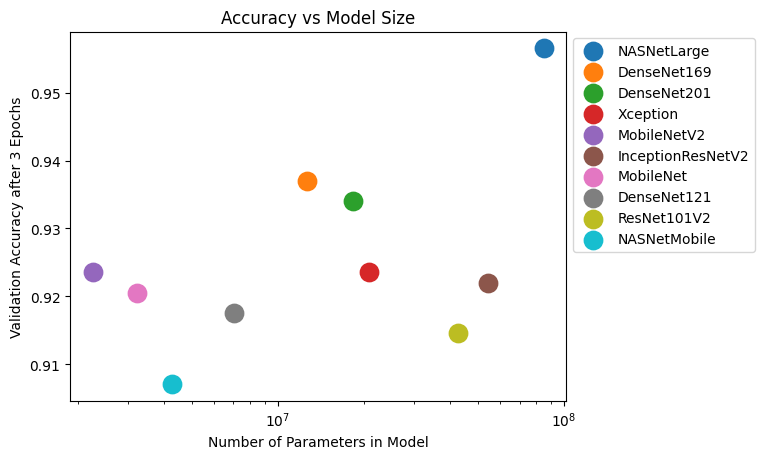

In [10]:
benchmark_df = pd.read_csv('benchmark.csv', sep=',')
benchmark_df = benchmark_df.sort_values(by='validation_accuracy', ascending=False)
benchmark_df = benchmark_df[:10]

plt.figurefigsize=(7,5)
for row in benchmark_df.itertuples():
    plt.scatter(row.num_model_params, row.validation_accuracy, label=row.model_name, s=150, linewidths=2)
    
plt.xscale('log')
plt.xlabel('Number of Parameters in Model')
plt.ylabel('Validation Accuracy after 3 Epochs')
plt.title('Accuracy vs Model Size')

plt.legend(bbox_to_anchor=(1,1), loc='upper left')

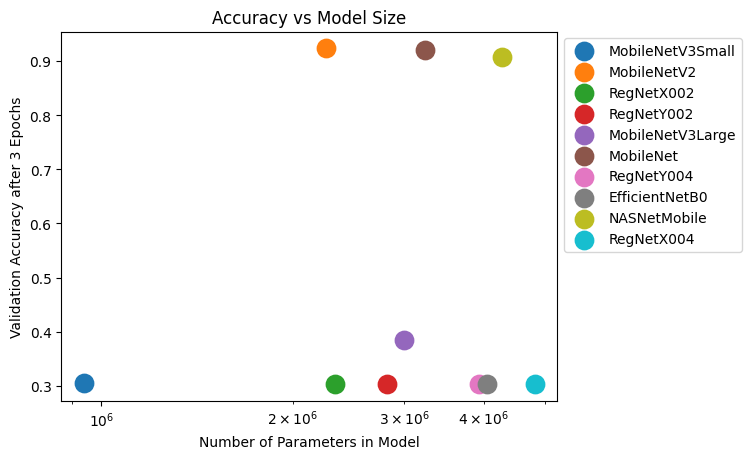

In [11]:
benchmark_df = pd.read_csv('benchmark.csv', sep=',')
benchmark_df = benchmark_df.sort_values(by='num_model_params', ascending=True)
benchmark_df = benchmark_df[:10]

plt.figurefigsize=(7,5)
for row in benchmark_df.itertuples():
    plt.scatter(row.num_model_params, row.validation_accuracy, label=row.model_name, s=150, linewidths=2)
    
plt.xscale('log')
plt.xlabel('Number of Parameters in Model')
plt.ylabel('Validation Accuracy after 3 Epochs')
plt.title('Accuracy vs Model Size')

plt.legend(bbox_to_anchor=(1,1), loc='upper left')